# **Dataset Play Tennis**

In [2]:
!pip install pandas numpy scikit-learn matplotlib

## 4.1 Persiapan Lingkungan

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 4.2 Load dan Eksplorasi Dataset Play Tennis

In [30]:
df =pd.read_csv(r'C:\Users\acer\Data Mining\Minggu 4\play_tennis.csv')
print(df.head())

  Day   Outlook Temperature Humidity    Wind PlayTennis
0  D1     Sunny         Hot     High    Weak         No
1  D2     Sunny         Hot     High  Strong         No
2  D3  Overcast         Hot     High    Weak        Yes
3  D4      Rain        Mild     High    Weak        Yes
4  D5      Rain        Cool   Normal    Weak        Yes


In [28]:
print(df['PlayTennis'].value_counts())

PlayTennis
Yes    9
No     5
Name: count, dtype: int64


## 4.3 Encoding Fitur Kategorikal

In [6]:
fitur = ['Outlook','Temperature','Humidity', 'Wind']
X = df[fitur].copy()
y = df['PlayTennis'].copy()

encoders = {}
X_enc = X.copy()
for col in fitur:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X[col])
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

y_le = LabelEncoder()
y_enc = y_le.fit_transform(y)

Outlook: {'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
Temperature: {'Cool': np.int64(0), 'Hot': np.int64(1), 'Mild': np.int64(2)}
Humidity: {'High': np.int64(0), 'Normal': np.int64(1)}
Wind: {'Strong': np.int64(0), 'Weak': np.int64(1)}


## 4.4 Membangun Model Decision Tree

In [7]:
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_enc, y_enc)
print(export_text(clf, feature_names=fitur))

|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Outlook >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



## 4.5 Visualisasi Pohon Keputusan

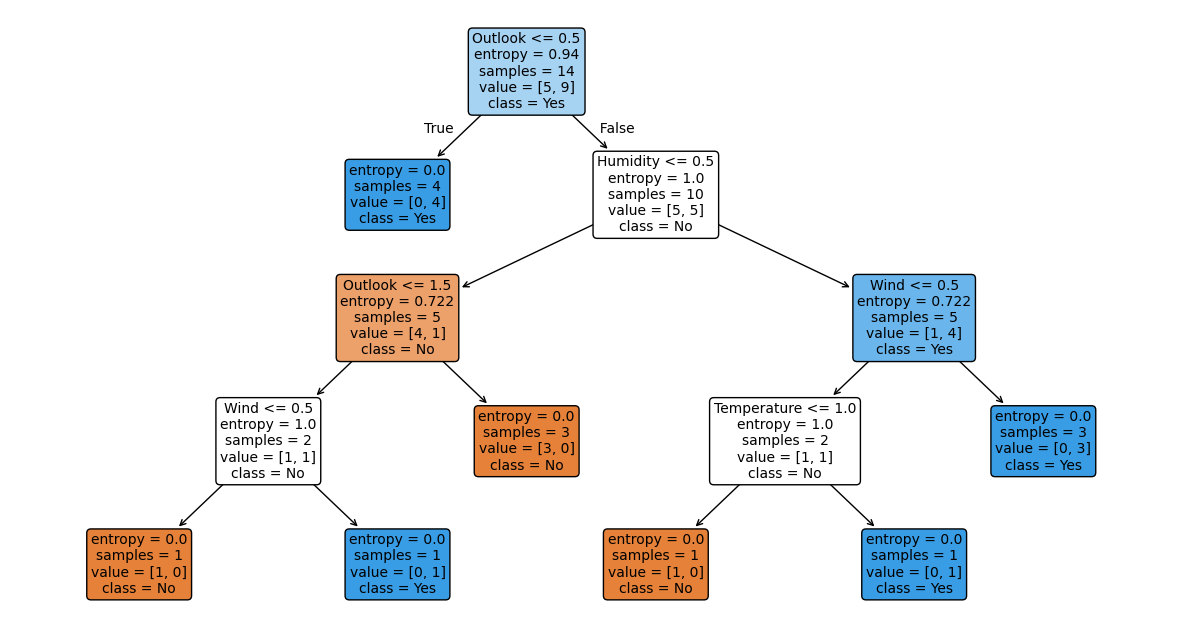

In [8]:
plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=fitur, class_names=y_le.classes_,
filled=True, rounded=True, fontsize=10, impurity=True)
plt.savefig('tree_play_tennis.png', dpi=180, bbox_inches='tight')
plt.show()

## 4.6 Prediksi Data Baru

In [9]:
data_baru=pd.DataFrame([{
'Outlook':'Sunny','Temperature':'Cool',
'Humidity':'High','Wind':'Strong'
}])
data_baru_enc=data_baru.copy()
for col in fitur:
    data_baru_enc[col] = encoders[col].transform(data_baru[col])
pred=clf.predict(data_baru_enc)
print('Prediksi:',y_le.inverse_transform(pred)[0])

Prediksi: No


## 4.7 Evaluasi Model dengan Dataset Iris

In [10]:
from sklearn.datasets import load_iris
iris=load_iris()
Xi =pd.DataFrame(iris.data,columns=iris.feature_names)
yi =iris.target
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    Xi, yi, test_size=0.3, random_state=42, stratify=yi)
print(f'Data latih: {len(Xi_train)} | Data uji: {len(Xi_test)}')

Data latih: 105 | Data uji: 45


In [11]:
clf_iris = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf_iris.fit(Xi_train, yi_train)
y_pred = clf_iris.predict(Xi_test)
print('Akurasi:', accuracy_score(yi_test, y_pred))
print(classification_report(yi_test, y_pred, target_names=iris.target_names, digits=3))

Akurasi: 0.9333333333333333
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      1.000     0.800     0.889        15
   virginica      0.833     1.000     0.909        15

    accuracy                          0.933        45
   macro avg      0.944     0.933     0.933        45
weighted avg      0.944     0.933     0.933        45



In [12]:
cm = confusion_matrix(yi_test, y_pred)
print(cm)

[[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]


## 4.8 Eksperimen: Pengaruh max_depth terhadap Akurasi

In [13]:
for depth in [1, 2, 3, 4, 5, None]:
    c = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    c.fit(Xi_train, yi_train)
    acc = accuracy_score(yi_test, c.predict(Xi_test))
    print(f'max_depth={depth}: akurasi = {acc:.4f}')

max_depth=1: akurasi = 0.6667
max_depth=2: akurasi = 0.8889
max_depth=3: akurasi = 0.9333
max_depth=4: akurasi = 0.8889
max_depth=5: akurasi = 0.8889
max_depth=None: akurasi = 0.8889


In [35]:
print('Feature Importance - Entropy')
for feature, importance in zip(Xi.columns, clf_iris.feature_importances_):
    print(f'{feature}: {importance:.3f}')

Feature Importance - Entropy
sepal length (cm): 0.029
sepal width (cm): 0.000
petal length (cm): 0.644
petal width (cm): 0.327


In [36]:
for depth in [1, 2, 3, 4, 5, None]:
    c = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    c.fit(Xi_train, yi_train)
    acc = accuracy_score(yi_test, c.predict(Xi_test))
    print(f'max_depth={depth}: akurasi = {acc:.4f}')

max_depth=1: akurasi = 0.6667
max_depth=2: akurasi = 0.8889
max_depth=3: akurasi = 0.9333
max_depth=4: akurasi = 0.8889
max_depth=5: akurasi = 0.8889
max_depth=None: akurasi = 0.8889


# **Penambahan 3 baris Data Baru ke dalam Dataset playtennis**

In [14]:
data_baru = pd.DataFrame({
    'Day': ['D15', 'D16', 'D17'],
    'Outlook': ['Sunny', 'Rain', 'Overcast'],
    'Temperature': ['Mild', 'Cool', 'Cool'],
    'Humidity': ['Normal', 'High', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak'],
    'PlayTennis': ['Yes', 'No', 'Yes']
})

df = pd.concat([df, data_baru], ignore_index=True)

df

,Day,Outlook,Temperature,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


In [15]:
fitur = ['Outlook','Temperature','Humidity', 'Wind']
X = df[fitur].copy()
y = df['PlayTennis'].copy()

encoders = {}
X_enc = X.copy()
for col in fitur:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X[col])
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

y_le = LabelEncoder()
y_enc = y_le.fit_transform(y)

Outlook: {'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
Temperature: {'Cool': np.int64(0), 'Hot': np.int64(1), 'Mild': np.int64(2)}
Humidity: {'High': np.int64(0), 'Normal': np.int64(1)}
Wind: {'Strong': np.int64(0), 'Weak': np.int64(1)}


In [16]:
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_enc, y_enc)
print(export_text(clf, feature_names=fitur))

|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- class: 0
|   |   |--- Wind >  0.50
|   |   |   |--- Outlook <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- Outlook >  1.50
|   |   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



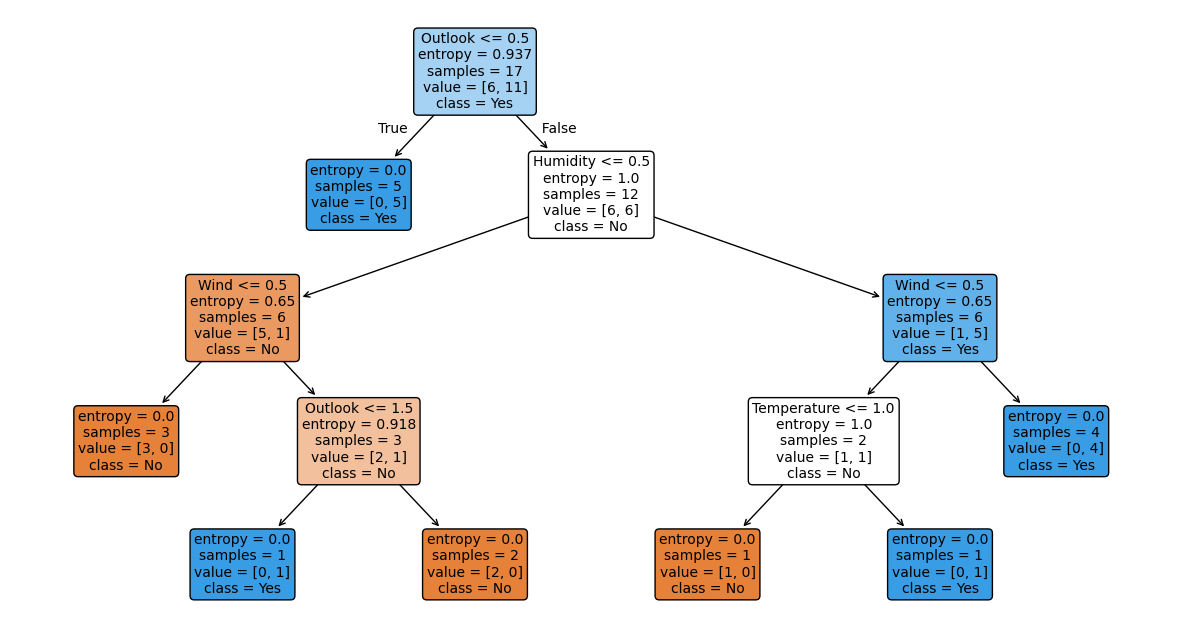

In [17]:
plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=fitur, class_names=y_le.classes_,
filled=True, rounded=True, fontsize=10, impurity=True)
plt.savefig('tree_play_tennis.png', dpi=180, bbox_inches='tight')
plt.show()

In [18]:
data_baru=pd.DataFrame([{
'Outlook':'Sunny','Temperature':'Cool',
'Humidity':'High','Wind':'Strong'
}])
data_baru_enc = data_baru.copy()
for col in fitur:
    data_baru_enc[col]=encoders[col].transform(data_baru[col])
pred=clf.predict(data_baru_enc)
print('Prediksi:',y_le.inverse_transform(pred)[0])

Prediksi: No


In [19]:
from sklearn.datasets import load_iris
iris=load_iris()
Xi =pd.DataFrame(iris.data,columns=iris.feature_names)
yi =iris.target
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    Xi, yi, test_size=0.3, random_state=42, stratify=yi)
print(f'Data latih: {len(Xi_train)} | Data uji: {len(Xi_test)}')

Data latih: 105 | Data uji: 45


In [20]:
clf_iris_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_iris_gini.fit(Xi_train, yi_train)
y_pred_gini = clf_iris_gini.predict(Xi_test)
print('Akurasi:', accuracy_score(yi_test, y_pred_gini))
print(classification_report(yi_test, y_pred_gini, target_names=iris.target_names, digits=3))

Akurasi: 0.9777777777777777
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      1.000     0.933     0.966        15
   virginica      0.938     1.000     0.968        15

    accuracy                          0.978        45
   macro avg      0.979     0.978     0.978        45
weighted avg      0.979     0.978     0.978        45



In [21]:
cm_gini = confusion_matrix(yi_test, y_pred_gini)
print('Confusion Matrix Gini:')
print(cm_gini)

Confusion Matrix Gini:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]


In [47]:
print('\nFeature Importance - Gini')
for feature, importance in zip(Xi.columns, clf_iris_gini.feature_importances_):
    print(f'{feature}: {importance:.3f}')


Feature Importance - Gini
sepal length (cm): 0.000
sepal width (cm): 0.000
petal length (cm): 0.551
petal width (cm): 0.449


# **Dataset Mahasiswa "Dataset Baru"**

## 1. Persiapan Lingkungan

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load dan Eksplorasi Dataset

In [75]:
df = pd.read_excel(r'D:\Semester5\Data Mining\Minggu 4\Dataset_Mahasiswa.xlsx')
print(df.head())

  Mahasiswa  Jam_Belajar  Kehadiran  Tugas  UTS  Lulus
0        M1            2         75     65   60  Tidak
1        M2            3         80     70   65  Tidak
2        M3            1         70     60   55  Tidak
3        M4            5         90     80   75     Ya
4        M5            6         95     85   82     Ya


In [76]:
print(df['Lulus'].value_counts())

Lulus
Tidak    32
Ya       18
Name: count, dtype: int64


## 3. Encoding Atribut

In [115]:
fitur = ['Jam_Belajar', 'Kehadiran', 'Tugas', 'UTS']
X = df[fitur].copy()
y = df['Lulus'].copy()

y_le = LabelEncoder()
y_enc = y_le.fit_transform(y)

print(f'Lulus: {dict(zip(y_le.classes_, y_le.transform(y_le.classes_)))}')

Lulus: {'Tidak': np.int64(0), 'Ya': np.int64(1)}


## 4. Split Data Latih/Uji

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Data latih :", len(X_train))
print("Data uji   :", len(X_test))

Data latih : 35
Data uji   : 15


## 5. Membangun Model Decision Tree

In [117]:
from sklearn.tree import DecisionTreeClassifier, export_text

clf = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

clf.fit(X_train, y_train)

print(export_text(clf, feature_names=fitur))

|--- UTS <= 71.00
|   |--- Kehadiran <= 94.50
|   |   |--- class: Tidak
|   |--- Kehadiran >  94.50
|   |   |--- UTS <= 61.50
|   |   |   |--- class: Ya
|   |   |--- UTS >  61.50
|   |   |   |--- class: Tidak
|--- UTS >  71.00
|   |--- Tugas <= 64.50
|   |   |--- class: Tidak
|   |--- Tugas >  64.50
|   |   |--- Kehadiran <= 99.50
|   |   |   |--- UTS <= 85.50
|   |   |   |   |--- UTS <= 75.50
|   |   |   |   |   |--- class: Ya
|   |   |   |   |--- UTS >  75.50
|   |   |   |   |   |--- UTS <= 81.00
|   |   |   |   |   |   |--- class: Tidak
|   |   |   |   |   |--- UTS >  81.00
|   |   |   |   |   |   |--- Kehadiran <= 95.50
|   |   |   |   |   |   |   |--- class: Ya
|   |   |   |   |   |   |--- Kehadiran >  95.50
|   |   |   |   |   |   |   |--- class: Tidak
|   |   |   |--- UTS >  85.50
|   |   |   |   |--- class: Ya
|   |   |--- Kehadiran >  99.50
|   |   |   |--- class: Tidak



## 6. Visualisasi Pohon Keputusan

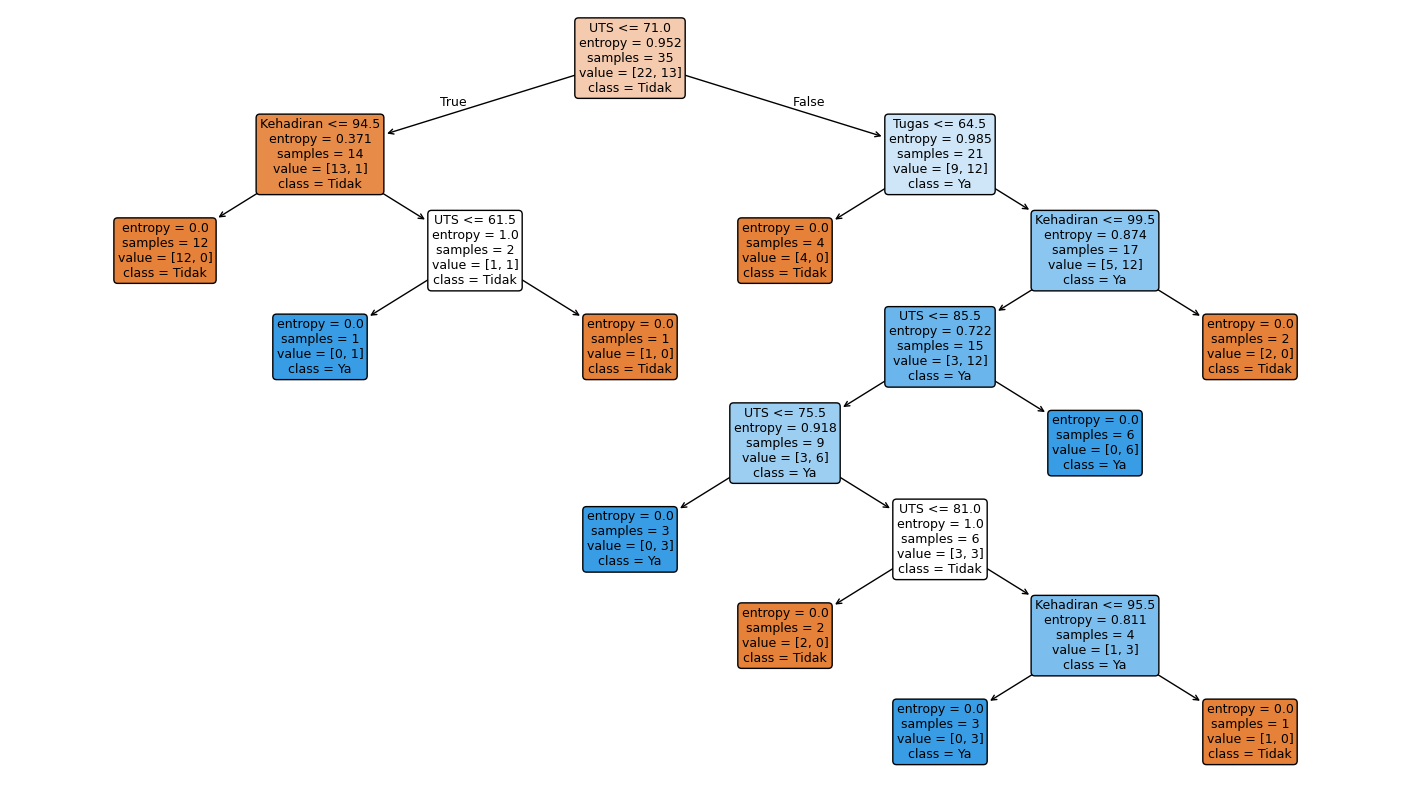

In [124]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    clf,
    feature_names=fitur,
    class_names=y_le.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()

## 7. Prediksi Data Baru

In [120]:
data_baru = pd.DataFrame([{
    'Jam_Belajar': 6,
    'Kehadiran': 90,
    'Tugas': 85,
    'UTS': 80
}])

pred = clf.predict(data_baru)

print('Prediksi:', pred[0])

Prediksi: Tidak


## 8. Evaluasi Model

In [121]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)

print("Akurasi:", akurasi)
print("Akurasi (%):", akurasi * 100, "%")

Akurasi: 0.7333333333333333
Akurasi (%): 73.33333333333333 %


In [122]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8 2]
 [2 3]]


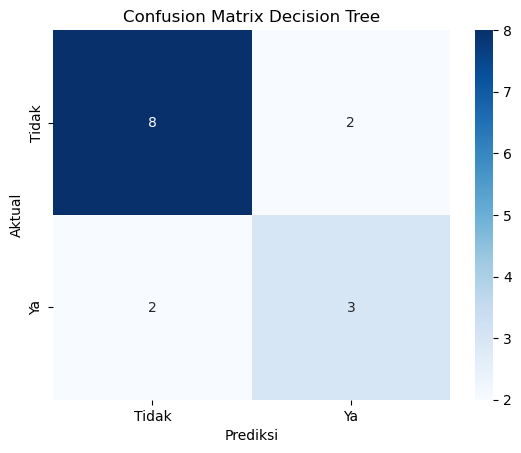

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=y_le.classes_,
    yticklabels=y_le.classes_
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Decision Tree')
plt.show()